In [2]:
from pathlib import Path
import ast
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

coupling_results_dir = Path(
    "/Users/arpitkapoor/Projects/groundwater/results/fno_henry_results/coupling_scenarios"
)
diffusion_results_dir = Path(
    "/Users/arpitkapoor/Projects/groundwater/results/fno_henry_results/diffusion_scenarios"
)

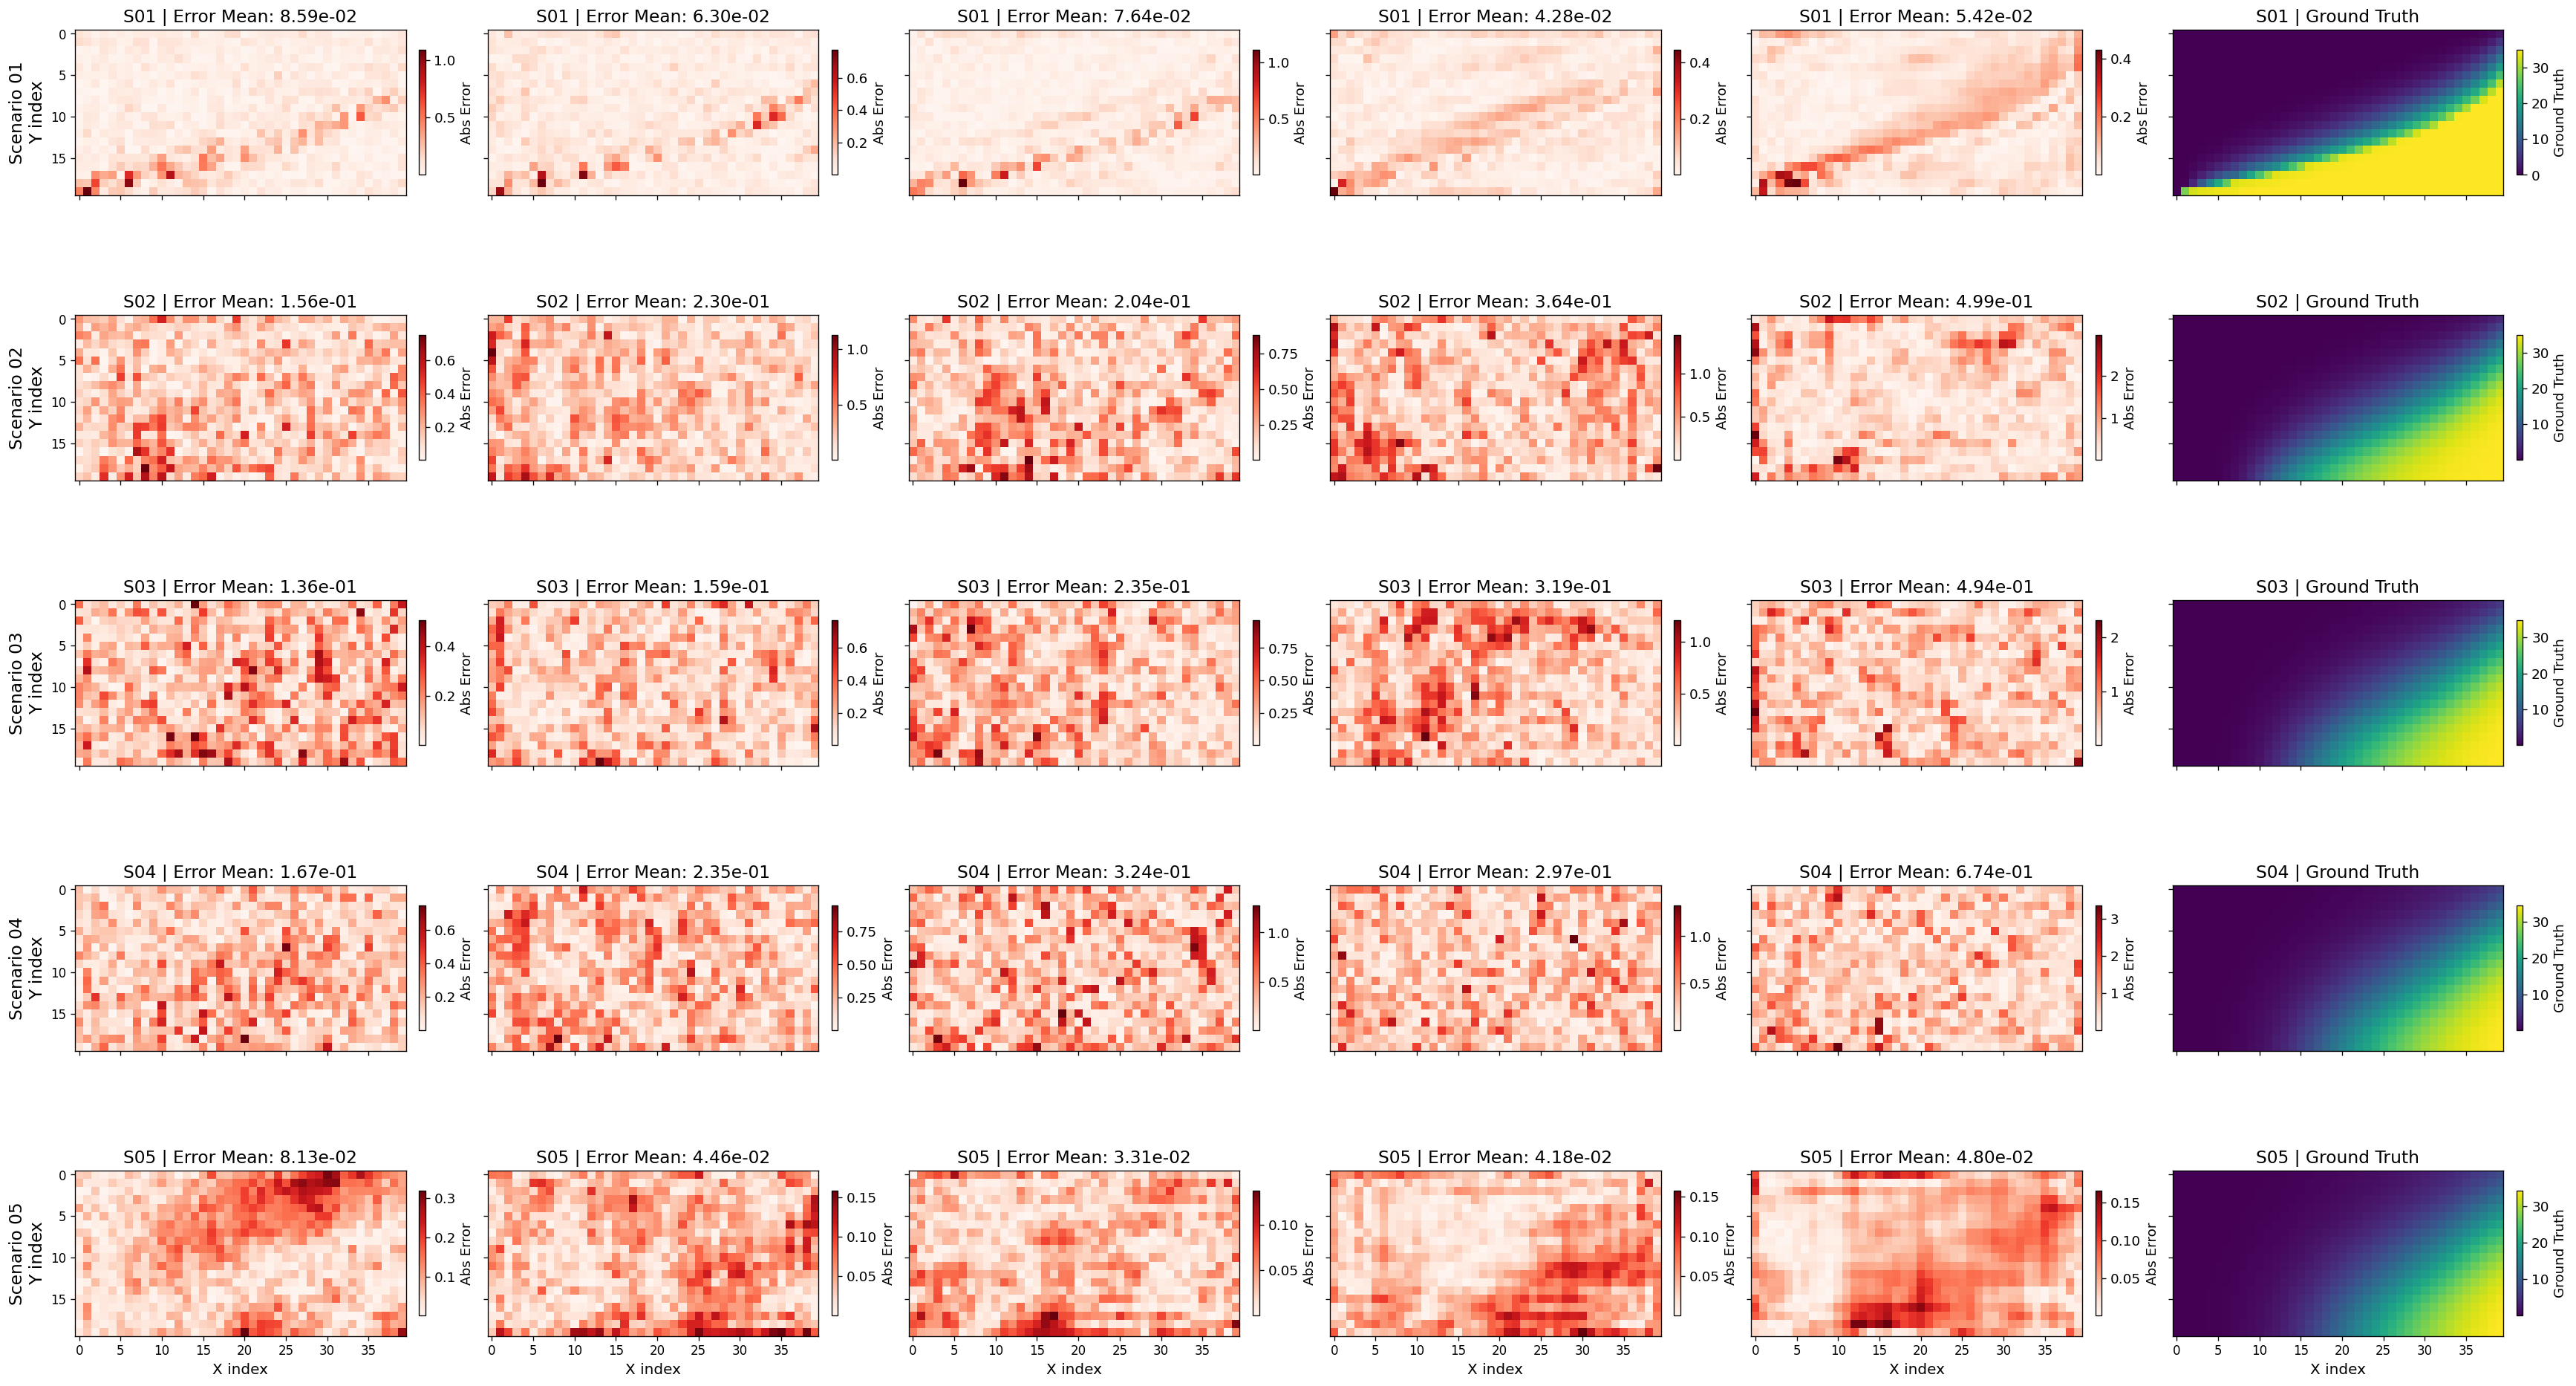

In [3]:
scenario_ids = [f"{i:02d}" for i in range(1, 6)]
scenario_errors = {}
scenario_truth = {}
max_error_cols = 0

def _extract_ground_truth_map(npz_data, err_map):
    # Prefer explicit ground-truth keys first.
    preferred_keys = [
        "target",
        "targets",
        "y_true",
        "truth",
        "ground_truth",
        "reference",
        "label",
        "labels",
    ]
    for key in preferred_keys:
        if key in npz_data:
            arr = np.asarray(npz_data[key])
            if arr.ndim >= 2:
                return np.squeeze(arr)

    # Fallback: choose a field with a compatible trailing shape (excluding abs_error).
    err_shape = np.asarray(err_map).shape
    for key in npz_data.files:
        if key == "abs_error":
            continue
        arr = np.asarray(npz_data[key])
        if arr.ndim >= 2 and tuple(arr.shape[-2:]) == tuple(err_shape[-2:]):
            return np.squeeze(arr)

    return None

for scenario_id in scenario_ids:
    scenario_files = sorted(
        diffusion_results_dir.glob(f"**/**/scenario_{scenario_id}*.npz")
    )
    errors = []
    gt_map_for_row = None

    for npz_file in scenario_files:
        data = np.load(npz_file, allow_pickle=True)
        err_map = np.asarray(data["abs_error"])[0]
        errors.append(err_map)

        if gt_map_for_row is None:
            gt_candidate = _extract_ground_truth_map(data, err_map)
            if gt_candidate is not None:
                # Keep only the first 2D slice if a higher-dimensional tensor is found.
                gt_map_for_row = np.asarray(gt_candidate)
                while gt_map_for_row.ndim > 2:
                    gt_map_for_row = gt_map_for_row[0]

    scenario_errors[scenario_id] = errors
    scenario_truth[scenario_id] = gt_map_for_row
    max_error_cols = max(max_error_cols, len(errors))

if max_error_cols == 0:
    raise ValueError("No scenario files found for scenario_01 to scenario_05.")

n_rows = len(scenario_ids)
n_cols = max_error_cols + 1  # Last column is ground truth.
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4.8 * n_cols, 3.2 * n_rows),
    constrained_layout=True,
    squeeze=False,
    sharex=True,
    sharey=True,
    dpi=120,
    facecolor="white",
)

for row_idx, scenario_id in enumerate(scenario_ids):
    row_errors = scenario_errors[scenario_id]

    # Error columns
    for col_idx in range(max_error_cols):
        ax = axes[row_idx, col_idx]

        if col_idx < len(row_errors):
            err_map = row_errors[col_idx]
            im = ax.imshow(err_map, cmap="Reds")
            ax.set_title(f"S{scenario_id} | Error Mean: {err_map.mean():.2e}", fontsize=14)
            cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, shrink=0.45)
            cbar.ax.tick_params(labelsize=11)
            cbar.set_label("Abs Error", fontsize=11)
        else:
            ax.axis("off")

    # Ground-truth column (last column)
    gt_ax = axes[row_idx, -1]
    gt_map = scenario_truth[scenario_id]
    if gt_map is not None:
        gt_im = gt_ax.imshow(gt_map, cmap="viridis")
        gt_ax.set_title(f"S{scenario_id} | Ground Truth", fontsize=14)
        gt_cbar = fig.colorbar(gt_im, ax=gt_ax, fraction=0.046, pad=0.04, shrink=0.45)
        gt_cbar.ax.tick_params(labelsize=11)
        gt_cbar.set_label("Ground Truth", fontsize=11)
    else:
        gt_ax.axis("off")
        gt_ax.set_title(f"S{scenario_id} | Ground Truth not found", fontsize=12)

    axes[row_idx, 0].set_ylabel(f"Scenario {scenario_id}\nY index", fontsize=14)

for ax in axes[-1, :]:
    if ax.has_data():
        ax.set_xlabel("X index", fontsize=12)

Scenario: 01, file: scenario_01_huge_val_final_step.npz, slice: y=10
Scenario: 02, file: scenario_02_huge_val_final_step.npz, slice: y=10
Scenario: 03, file: scenario_03_huge_val_final_step.npz, slice: y=10
Scenario: 04, file: scenario_04_huge_val_final_step.npz, slice: y=10
Scenario: 05, file: scenario_05_huge_val_final_step.npz, slice: y=10


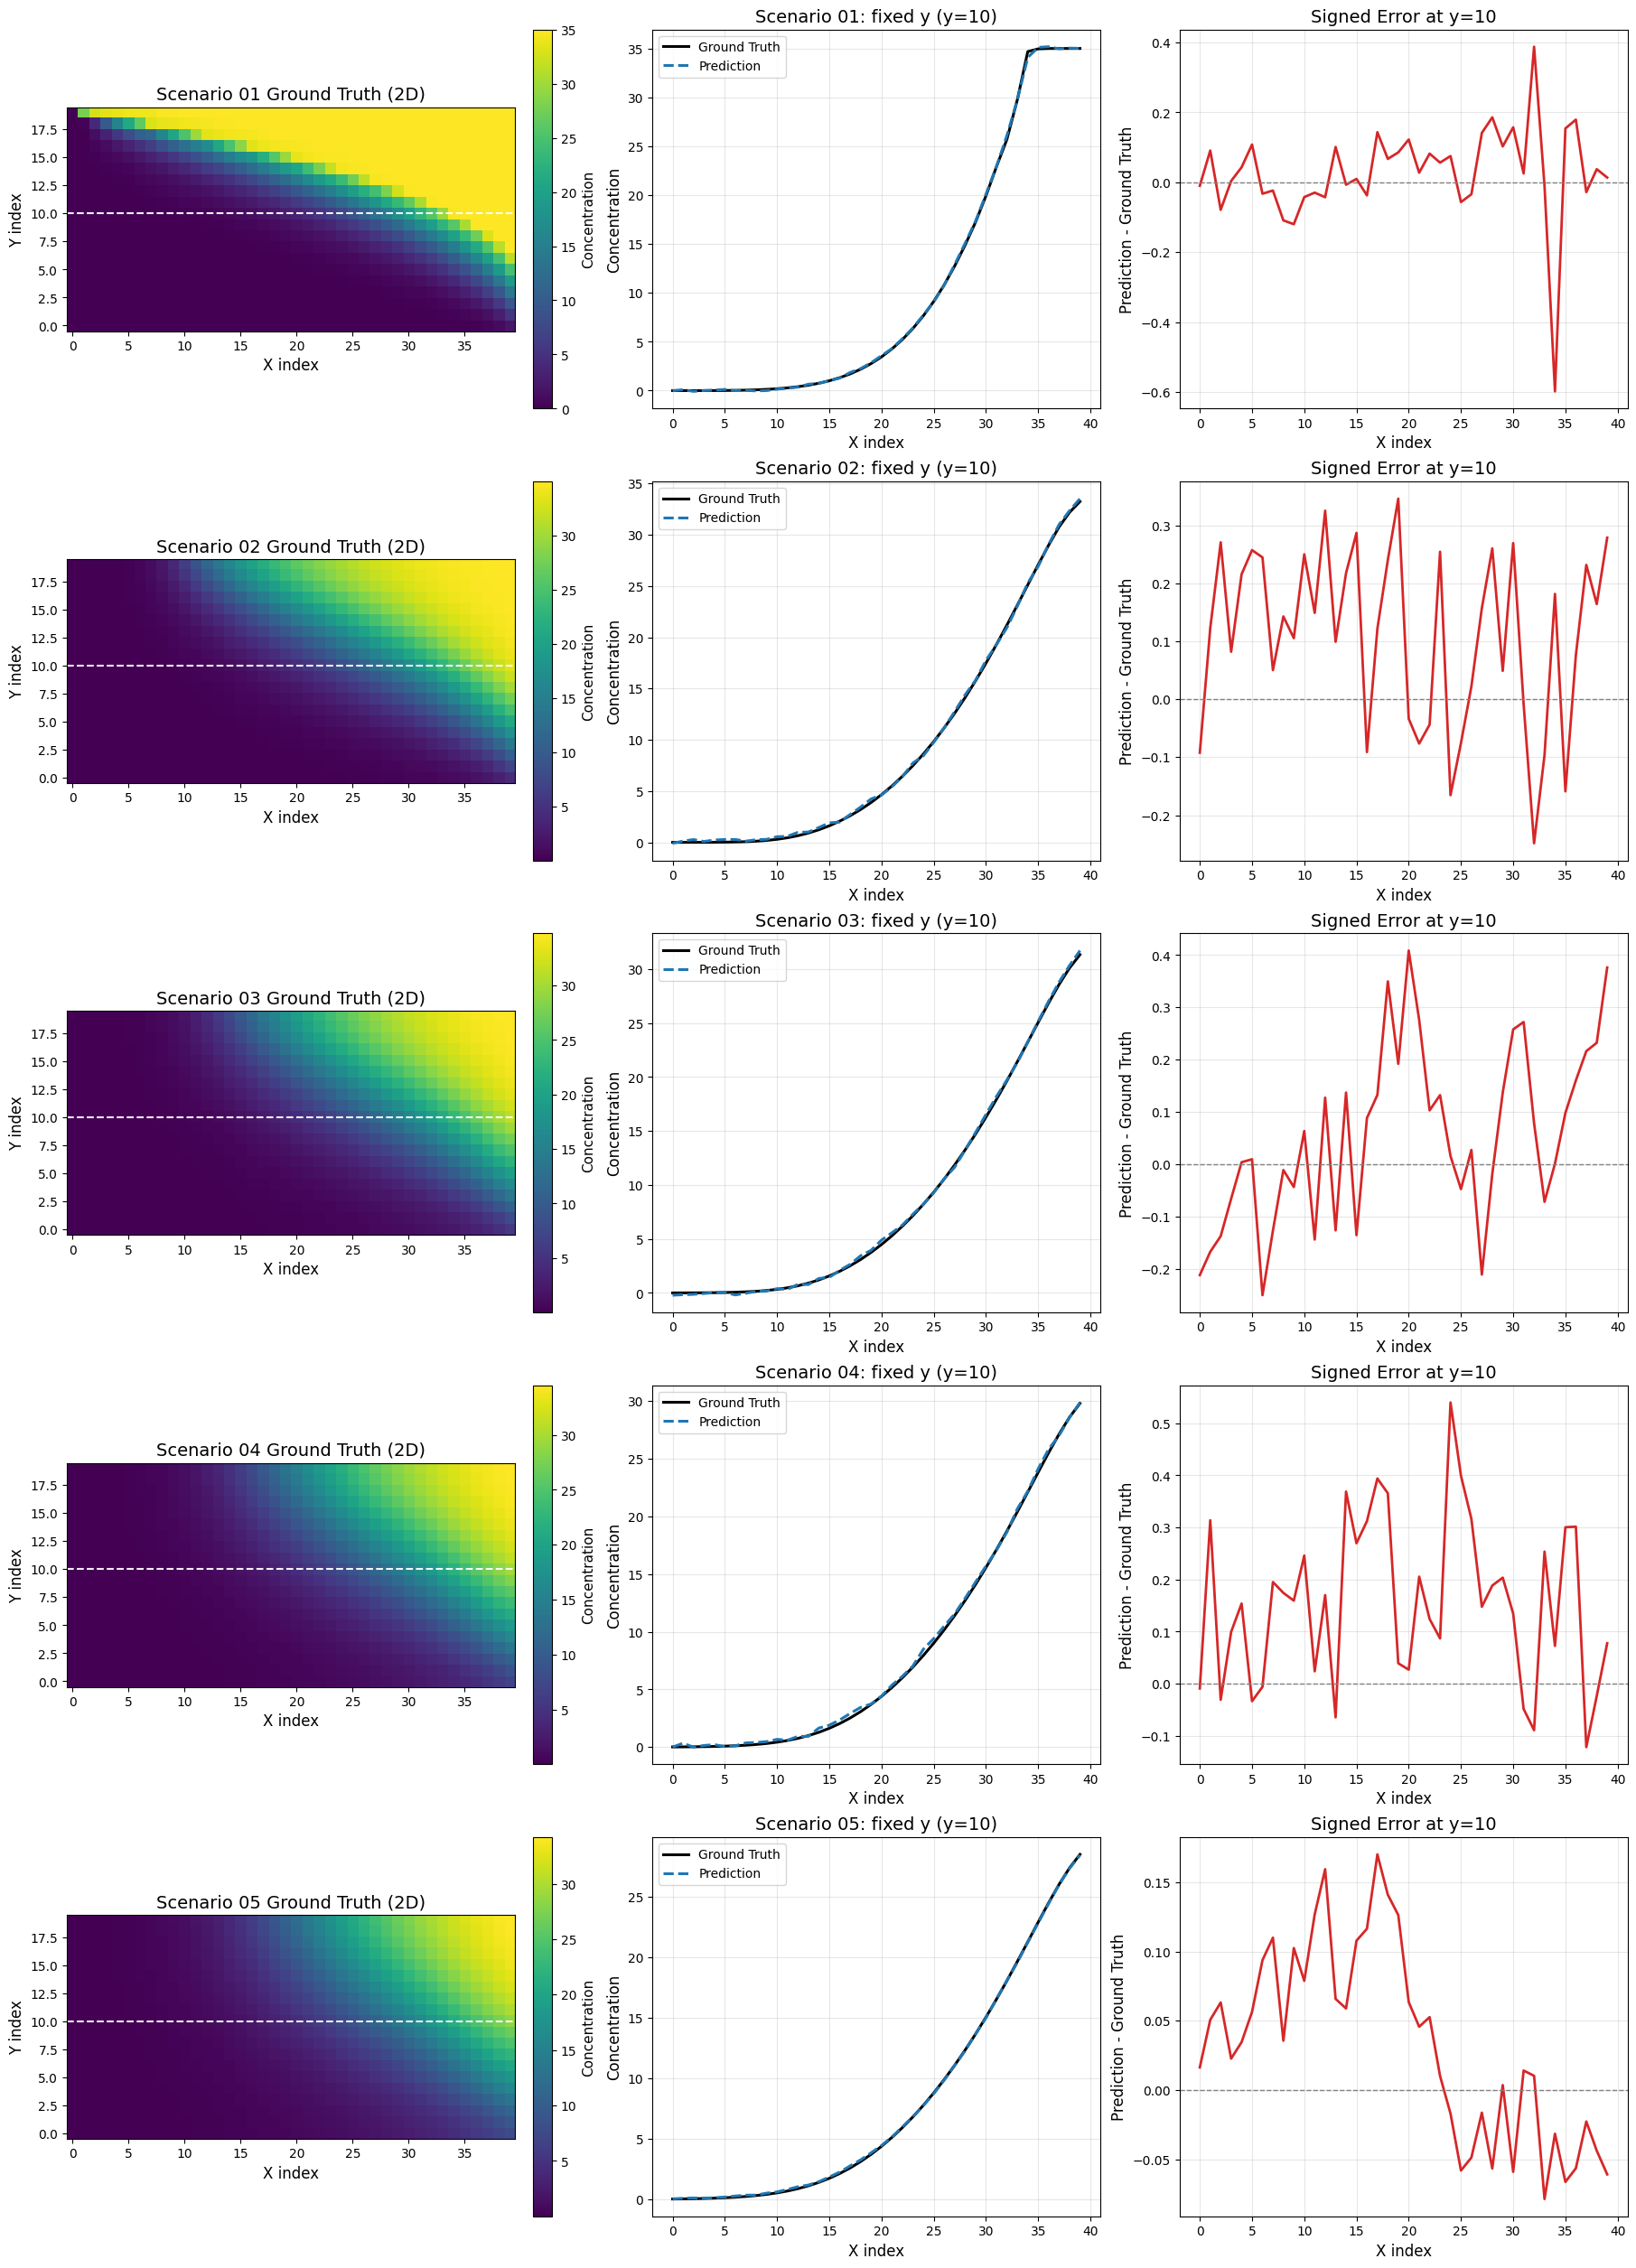

In [4]:
# Multi-row comparison: one row per scenario, thesis-style cross-section comparison.
scenario_ids_for_slice = [f"{i:02d}" for i in range(1, 6)]
npz_index = 0              # file index within each scenario
slice_direction = "x"      # "x" -> c(x, y_fixed), "y" -> c(x_fixed, y)
fixed_index = None         # None -> middle index for chosen direction

def _extract_ground_truth_map_local(npz_data, err_map):
    preferred_keys = [
        "target",
        "targets",
        "y_true",
        "truth",
        "ground_truth",
        "reference",
        "label",
        "labels",
    ]
    for key in preferred_keys:
        if key in npz_data:
            arr = np.asarray(npz_data[key])
            if arr.ndim >= 2:
                return np.squeeze(arr)

    err_shape = np.asarray(err_map).shape
    for key in npz_data.files:
        if key == "abs_error":
            continue
        arr = np.asarray(npz_data[key])
        if arr.ndim >= 2 and tuple(arr.shape[-2:]) == tuple(err_shape[-2:]):
            return np.squeeze(arr)

    return None

def _extract_prediction_map_local(npz_data, gt_shape):
    preferred_keys = [
        "pred",
        "prediction",
        "predictions",
        "y_pred",
        "output",
        "outputs",
        "recon",
    ]
    for key in preferred_keys:
        if key in npz_data:
            arr = np.asarray(npz_data[key])
            arr = np.squeeze(arr)
            while arr.ndim > 2:
                arr = arr[0]
            if arr.shape == gt_shape:
                return arr

    for key in npz_data.files:
        lower = key.lower()
        if key == "abs_error" or "target" in lower or "truth" in lower or "label" in lower:
            continue
        arr = np.asarray(npz_data[key])
        arr = np.squeeze(arr)
        while arr.ndim > 2:
            arr = arr[0]
        if arr.ndim == 2 and arr.shape == gt_shape:
            return arr

    return None

rows = []
for scenario_id in scenario_ids_for_slice:
    scenario_files = sorted(
        diffusion_results_dir.glob(f"**/**/scenario_{scenario_id}*.npz")
    )
    if not scenario_files:
        print(f"Skipping scenario {scenario_id}: no files found")
        continue
    if npz_index >= len(scenario_files):
        print(
            f"Skipping scenario {scenario_id}: npz_index={npz_index} out of range "
            f"for {len(scenario_files)} files"
        )
        continue

    data = np.load(scenario_files[npz_index], allow_pickle=True)
    err_map = np.asarray(data["abs_error"])[0]

    if "_extract_ground_truth_map" in globals():
        gt_map = _extract_ground_truth_map(data, err_map)
    else:
        gt_map = _extract_ground_truth_map_local(data, err_map)

    if gt_map is None:
        print(f"Skipping scenario {scenario_id}: ground truth not found")
        continue

    gt_map = np.asarray(gt_map)
    while gt_map.ndim > 2:
        gt_map = gt_map[0]

    pred_map = _extract_prediction_map_local(data, gt_map.shape)
    if pred_map is None:
        print(f"Skipping scenario {scenario_id}: prediction not found")
        continue

    ny, nx = gt_map.shape
    if slice_direction.lower() == "x":
        idx = ny // 2 if fixed_index is None else int(fixed_index)
        if not (0 <= idx < ny):
            raise IndexError(f"fixed_index={idx} out of bounds for y in [0, {ny - 1}].")
        axis_coords = np.arange(nx)
        gt_slice = gt_map[idx, :]
        pred_slice = pred_map[idx, :]
        coord_label = f"y={idx}"
        x_label = "X index"
        slice_title = f"Scenario {scenario_id}: fixed y ({coord_label})"
    else:
        idx = nx // 2 if fixed_index is None else int(fixed_index)
        if not (0 <= idx < nx):
            raise IndexError(f"fixed_index={idx} out of bounds for x in [0, {nx - 1}].")
        axis_coords = np.arange(ny)
        gt_slice = gt_map[:, idx]
        pred_slice = pred_map[:, idx]
        coord_label = f"x={idx}"
        x_label = "Y index"
        slice_title = f"Scenario {scenario_id}: fixed x ({coord_label})"

    signed_diff = pred_slice - gt_slice
    rows.append(
        {
            "scenario_id": scenario_id,
            "file_name": scenario_files[npz_index].name,
            "gt_map": gt_map,
            "idx": idx,
            "coord_label": coord_label,
            "x_label": x_label,
            "slice_title": slice_title,
            "axis_coords": axis_coords,
            "gt_slice": gt_slice,
            "pred_slice": pred_slice,
            "signed_diff": signed_diff,
        }
    )

if not rows:
    raise ValueError("No scenarios could be plotted. Check file availability and NPZ keys.")

n_rows = len(rows)
fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5 * n_rows), constrained_layout=True, squeeze=False)

for r, row in enumerate(rows):
    # Column 1: 2D ground truth with selected slice location
    im = axes[r, 0].imshow(row["gt_map"], cmap="viridis", origin="lower")
    if slice_direction.lower() == "x":
        axes[r, 0].axhline(row["idx"], color="white", linestyle="--", linewidth=1.5, alpha=0.95)
    else:
        axes[r, 0].axvline(row["idx"], color="white", linestyle="--", linewidth=1.5, alpha=0.95)
    axes[r, 0].set_title(f"Scenario {row['scenario_id']} Ground Truth (2D)", fontsize=14)
    axes[r, 0].set_xlabel("X index", fontsize=12)
    axes[r, 0].set_ylabel("Y index", fontsize=12)
    cbar = fig.colorbar(im, ax=axes[r, 0], fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=10)
    cbar.set_label("Concentration", fontsize=11)

    # Column 2: Ground truth vs prediction at selected slice
    axes[r, 1].plot(row["axis_coords"], row["gt_slice"], color="black", linewidth=2.2, label="Ground Truth")
    axes[r, 1].plot(
        row["axis_coords"],
        row["pred_slice"],
        color="#1f77b4",
        linewidth=2.2,
        linestyle="--",
        label="Prediction",
    )
    axes[r, 1].set_title(row["slice_title"], fontsize=14)
    axes[r, 1].set_xlabel(row["x_label"], fontsize=12)
    axes[r, 1].set_ylabel("Concentration", fontsize=12)
    axes[r, 1].grid(True, alpha=0.3)
    axes[r, 1].legend(fontsize=10)

    # Column 3: Signed error profile (Prediction - Ground Truth)
    axes[r, 2].plot(row["axis_coords"], row["signed_diff"], color="#d62728", linewidth=2.0)
    axes[r, 2].axhline(0.0, color="gray", linestyle="--", linewidth=1)
    axes[r, 2].set_title(f"Signed Error at {row['coord_label']}", fontsize=14)
    axes[r, 2].set_xlabel(row["x_label"], fontsize=12)
    axes[r, 2].set_ylabel("Prediction - Ground Truth", fontsize=12)
    axes[r, 2].grid(True, alpha=0.3)

for ax_row in axes:
    for ax in ax_row:
        ax.tick_params(labelsize=10)

for row in rows:
    print(
        f"Scenario: {row['scenario_id']}, file: {row['file_name']}, "
        f"slice: {row['coord_label']}"
    )

# Grid Scenarios

In [5]:
import os
grid_results_dir = Path(os.path.expanduser("~/Projects/groundwater/results/fno_henry_results/training_04/"))
grid_results_csv = grid_results_dir / "scenarios_run_000003_fno_sweep_per_scenario_results.csv"
grid_results_df = pd.read_csv(grid_results_csv)
grid_results_df.head()

,timestamp,scenario_collection,validation_tag,scenario_name,model_size_label,hidden_channels,n_modes_x,n_modes_y,n_layers,eval_every,train_l2,train_mse,val_l2,val_mse,train_plot,val_plot
0,2026-04-26T07:25:29,scenarios,run_000003,scenario_01,tiny,64,8,16,2,1,0.004306,0.004951,0.006131,0.006825,results/validation_final_step_artifacts/scenar...,results/validation_final_step_artifacts/scenar...
1,2026-04-26T07:25:29,scenarios,run_000003,scenario_02,tiny,64,8,16,2,1,0.002926,0.002367,0.003677,0.002877,results/validation_final_step_artifacts/scenar...,results/validation_final_step_artifacts/scenar...
2,2026-04-26T07:25:29,scenarios,run_000003,scenario_03,tiny,64,8,16,2,1,0.002571,0.001691,0.003107,0.001969,results/validation_final_step_artifacts/scenar...,results/validation_final_step_artifacts/scenar...
3,2026-04-26T07:25:29,scenarios,run_000003,scenario_04,tiny,64,8,16,2,1,0.002511,0.001400,0.002998,0.001573,results/validation_final_step_artifacts/scenar...,results/validation_final_step_artifacts/scenar...
4,2026-04-26T07:25:29,scenarios,run_000003,scenario_05,tiny,64,8,16,2,1,0.002672,0.001320,0.003219,0.001454,results/validation_final_step_artifacts/scenar...,results/validation_final_step_artifacts/scenar...


Scenarios found in CSV: ['scenario_01', 'scenario_02', 'scenario_03', 'scenario_04', 'scenario_05', 'scenario_06', 'scenario_07', 'scenario_08', 'scenario_09', 'scenario_10', 'scenario_11', 'scenario_12', 'scenario_13', 'scenario_14', 'scenario_15', 'scenario_16', 'scenario_17', 'scenario_18', 'scenario_19', 'scenario_20', 'scenario_21', 'scenario_22', 'scenario_23', 'scenario_24', 'scenario_25']


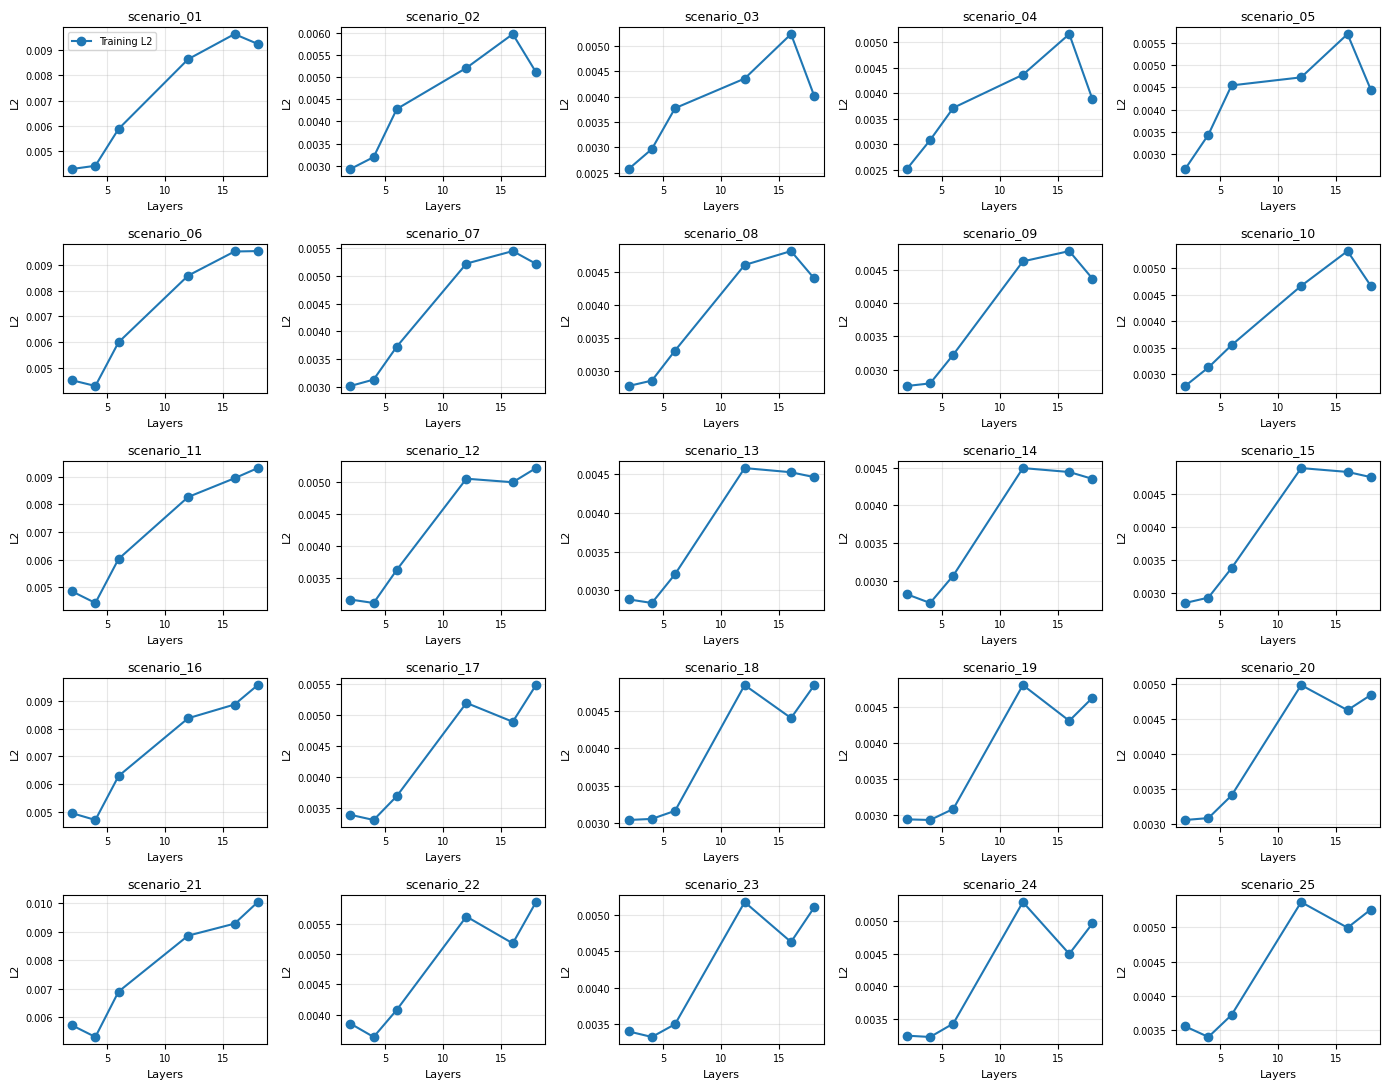

In [9]:
scenario_list = sorted(grid_results_df["scenario_name"].unique())
print("Scenarios found in CSV:", scenario_list)

# Parse scenario numbers (scenario_01 -> 1, ...)
scenario_nums = [int(s.split("_")[1]) for s in scenario_list]
n_scenarios = len(scenario_nums)

# 5 columns layout, rows computed from number of scenarios
n_cols = 5
n_rows = math.ceil(n_scenarios / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.8 * n_cols, 2.2 * n_rows), squeeze=False)

for scenario in scenario_list:
    scenario_data = grid_results_df[grid_results_df["scenario_name"] == scenario].sort_values("n_layers")

    scenario_num = int(scenario.split("_")[1])
    idx0 = scenario_num - 1  # zero-based index

    r, c = divmod(idx0, n_cols)
    ax = axes[r, c]

    # ax.plot(scenario_data["n_layers"], scenario_data["val_l2"], marker="o", label="Validation L2")
    ax.plot(scenario_data["n_layers"], scenario_data["train_l2"], marker="o", label="Training L2")
    ax.set_title(scenario, fontsize=9)
    ax.set_xlabel("Layers", fontsize=8)
    ax.set_ylabel("L2", fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=7)

# Hide any unused subplots
for k in range(n_scenarios, n_rows * n_cols):
    r, c = divmod(k, n_cols)
    axes[r, c].axis("off")

# Single legend
axes[0, 0].legend(fontsize=7)
plt.tight_layout()
plt.show()


In [10]:
grid_results_df.groupby('model_size_label').agg(
    n_layers=pd.NamedAgg(column='n_layers', aggfunc='mean')
)

,n_layers
model_size_label,
huge,16.0
large,12.0
massive,18.0
medium,6.0
small,4.0
tiny,2.0


In [19]:
list(grid_results_dir.glob("**/**/*.npz"))

[PosixPath('/Users/arpitkapoor/Projects/groundwater/results/fno_henry_results/training_04/run_000003/scenarios_run_000003_large_val_all_steps.npz'),
 PosixPath('/Users/arpitkapoor/Projects/groundwater/results/fno_henry_results/training_04/run_000003/scenarios_run_000003_small_val_all_steps.npz'),
 PosixPath('/Users/arpitkapoor/Projects/groundwater/results/fno_henry_results/training_04/run_000003/scenarios_run_000003_massive_val_all_steps.npz'),
 PosixPath('/Users/arpitkapoor/Projects/groundwater/results/fno_henry_results/training_04/run_000003/scenarios_run_000003_medium_val_all_steps.npz'),
 PosixPath('/Users/arpitkapoor/Projects/groundwater/results/fno_henry_results/training_04/run_000003/scenarios_run_000003_tiny_val_all_steps.npz'),
 PosixPath('/Users/arpitkapoor/Projects/groundwater/results/fno_henry_results/training_04/run_000003/scenarios_run_000003_huge_val_all_steps.npz'),
 PosixPath('/Users/arpitkapoor/Projects/groundwater/results/fno_henry_results/training_04/run_000003/per_

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

npz_files = sorted(grid_results_dir.glob("**/per_scenario/*.npz"))

error_map_store = []
for npz_file in npz_files:
    if "val_all" not in npz_file.name.lower():
        continue

    res_data = np.load(npz_file, allow_pickle=True)

    parts = npz_file.stem.split("_")
    if len(parts) < 3:
        continue

    scenario = parts[1]
    size_label = parts[2]

    size_label_to_layers = {
        "tiny": 2,
        "small": 4,
        "medium": 6,
        "large": 12,
        "huge": 16,
        "massive": 18,
    }
    n_layers = size_label_to_layers.get(size_label, "Unknown")

    error_map = np.asarray(res_data["abs_error_all"][:, 0].mean(axis=0))

    error_map_store.append(
        {
            "scenario": scenario,
            "size_label": size_label,
            "n_layers": n_layers,
            "error_map": error_map,
        }
    )

model_options = sorted({item["size_label"] for item in error_map_store})
model_dropdown = widgets.Dropdown(
    options=model_options,
    value=model_options[0] if model_options else None,
    description="Model:",
    disabled=not model_options,
)

output = widgets.Output()

def plot_error_maps(selected_model):
    with output:
        clear_output(wait=True)

        selected = [item for item in error_map_store if item["size_label"] == selected_model]
        if not selected:
            print("No error maps found for the selected model.")
            return

        selected = sorted(selected, key=lambda d: int(d["scenario"]))

        n_maps = len(selected)
        n_cols = 5
        n_rows = int(np.ceil(n_maps / n_cols))

        fig_w = 3.2 * n_cols + 0.8
        fig_h = 1.8 * n_rows + 0.8

        fig = plt.figure(figsize=(fig_w, fig_h), constrained_layout=True)
        gs = fig.add_gridspec(
            n_rows, n_cols + 1,
            width_ratios=[1] * n_cols + [0.06]
        )

        axes = []
        for r in range(n_rows):
            for c in range(n_cols):
                axes.append(fig.add_subplot(gs[r, c]))
        cax = fig.add_subplot(gs[:, -1])  # fixed colorbar axis at far right

        all_vals = np.concatenate([d["error_map"].ravel() for d in selected])
        vmin = np.nanmin(all_vals)
        vmax = np.nanpercentile(all_vals, 99.5)
        if vmax <= vmin:
            vmax = np.nanmax(all_vals)

        im = None
        for i, item in enumerate(selected):
            ax = axes[i]
            im = ax.imshow(item["error_map"], cmap="Reds", vmin=vmin, vmax=vmax, aspect="auto")
            ax.set_title(f"Scenario {item['scenario']} | MAE: {item['error_map'].mean():.2f}", fontsize=9)
            ax.axis("off")

        for j in range(n_maps, len(axes)):
            axes[j].axis("off")

        fig.suptitle(f"Absolute Error Maps | Model: {selected_model} | Layers: {item['n_layers']}", fontsize=14)

        if im is not None:
            cbar = fig.colorbar(im, cax=cax)
            cbar.set_label("Absolute Error", fontsize=10)
            cbar.ax.tick_params(labelsize=9)

        plt.show()

def _on_change(change):
    if change["name"] == "value":
        plot_error_maps(change["new"])

model_dropdown.observe(_on_change, names="value")

display(model_dropdown, output)
plot_error_maps(model_dropdown.value)


Dropdown(description='Model:', options=('huge', 'large', 'massive', 'medium', 'small', 'tiny'), value='huge')

Output()